In [9]:
import matplotlib.pyplot
import numpy as np 
from scipy.optimize import fsolve
import matplotlib.pyplot as plt 
from scipy.special import gamma 
import matplotlib
from tqdm import * 

from src.FDE02solver import * 

# Setting

In [10]:
tolerances = [1e-6,1e-8,1e-10,1e-12,1e-14,1e-16,1e-18,1e-20]

filesG6 = {}
filesG6[1e-2]  = 'data/RA_DO/distExpGamma6_m_2_AAAtol_0.01.csv'
filesG6[1e-4]  = 'data/RA_DO/distExpGamma6_m_5_AAAtol_0.0001.csv'
filesG6[1e-6]  = 'data/RA_DO/distExpGamma6_m_10_AAAtol_1.0e-6.csv'
filesG6[1e-8]  = 'data/RA_DO/distExpGamma6_m_15_AAAtol_1.0e-8.csv'
filesG6[1e-10] = 'data/RA_DO/distExpGamma6_m_20_AAAtol_1.0e-10.csv'
filesG6[1e-12] = 'data/RA_DO/distExpGamma6_m_25_AAAtol_1.0e-12.csv'
filesG6[1e-14] = 'data/RA_DO/distExpGamma6_m_29_AAAtol_1.0e-14.csv'
filesG6[1e-16] = 'data/RA_DO/distExpGamma6_m_34_AAAtol_1.0e-16.csv'
filesG6[1e-18] = 'data/RA_DO/distExpGamma6_m_40_AAAtol_1.0e-18.csv'
filesG6[1e-20] = 'data/RA_DO/distExpGamma6_m_45_AAAtol_1.0e-20.csv'

filesG6[1e-40] = 'data/RA_DO/distExpGamma6_m_92_AAAtol_1.0e-40.csv'

filesG5 = {}
filesG5[1e-2]  = 'data/RA_DO/distExpGamma5_m_2_AAAtol_0.01.csv'
filesG5[1e-4]  = 'data/RA_DO/distExpGamma5_m_5_AAAtol_0.0001.csv'
filesG5[1e-6]  = 'data/RA_DO/distExpGamma5_m_10_AAAtol_1.0e-6.csv'
filesG5[1e-8]  = 'data/RA_DO/distExpGamma5_m_14_AAAtol_1.0e-8.csv'
filesG5[1e-10] = 'data/RA_DO/distExpGamma5_m_20_AAAtol_1.0e-10.csv'
filesG5[1e-12] = 'data/RA_DO/distExpGamma5_m_25_AAAtol_1.0e-12.csv'
filesG5[1e-14] = 'data/RA_DO/distExpGamma5_m_30_AAAtol_1.0e-14.csv'
filesG5[1e-16] = 'data/RA_DO/distExpGamma5_m_34_AAAtol_1.0e-16.csv'
filesG5[1e-18] = 'data/RA_DO/distExpGamma5_m_40_AAAtol_1.0e-18.csv'

filesG5[1e-20] = 'data/RA_DO/distExpGamma5_m_44_AAAtol_1.0e-20.csv'

filesG5[1e-40] = 'data/RA_DO/distExpGamma5_m_91_AAAtol_1.0e-40.csv'

def rhs(t,y): 
    return 120 * (np.exp(1)**2 *t**5 - t**3) / (np.exp(1)**2 * (np.log(t) + 1)) \
        + np.cos(100 * (y / (1 + y**0.5))) \
        - np.cos(100 * (t**5 / (1 + t**2.5))) 

def sol(t): 
    return t**5 

phi_str = r"$\phi(\alpha) = e^{-\alpha}\Gamma(6-\alpha), \alpha \in [0,2]$" 

# Numerical Computations

In [11]:
hs_RA = np.geomspace(0.1,0.001,9)

scheme = "RIIA3"
Linferror_ = {} 

for idt, tol in enumerate(tolerances): 

    data01 = np.genfromtxt(filesG6[tol], delimiter=',')
    weights01 = data01[0,:]
    exponents01 = -data01[1,:] 
    data12 = np.genfromtxt(filesG5[tol], delimiter=',')
    weights12 = data12[0,:]
    exponents12 = -data12[1,:] 

    Linferror_[tol] = [] 
    for h in hs_RA: 
        COFDE = FDE02RK(weights01=weights01, exponents01=exponents01, 
                        weights12=weights12, exponents12=exponents12, 
                        f=rhs, t0=0, u0=np.array([0]), v0=np.array([0]), tf=1, h=h, scheme=scheme)
        times, numsol = COFDE.solve()
        error = np.abs(numsol[:,0] - sol(times))

        Linferror_[tol].append(np.max(error))

Linferror_RA = Linferror_



  0%|          | 0/31 [00:00<?, ?it/s]/home/jonas/.local/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
100%|██████████| 1000/1000 [00:02<00:00, 483.63it/s]


In [ ]:
schemes = ["RIIA1" , "RIIA2", "RIIA3"]

hs_h = np.geomspace(0.1,0.001,13)

data01 = np.genfromtxt(filesG6[1e-40], delimiter=',')
weights01 = data01[0,:]
exponents01 = -data01[1,:] 
data12 = np.genfromtxt(filesG5[1e-40], delimiter=',')
weights12 = data12[0,:]
exponents12 = -data12[1,:] 

Linferror_ = {} 

for idx, scheme in enumerate(schemes):
    Linferror_[scheme] = [] 
    for h in hs_h: 
        COFDE = FDE02RK(weights01=weights01, exponents01=exponents01, 
                        weights12=weights12, exponents12=exponents12, 
                        f=rhs, t0=0, u0=np.array([0]), v0=np.array([0]), tf=1, h=h, scheme=scheme)
        times, numsol = COFDE.solve()
        error = np.abs(numsol[:,0] - sol(times))

        Linferror_[scheme].append(np.max(error))

Linferror_h = Linferror_

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_44828/2429807653.py:34: RuntimeWarning: invalid value encountered in double_scalars
  + np.cos(100 * (y / (1 + y**0.5))) \
  0%|          | 0/31 [00:00<?, ?it/s]

# Visualisation

In [ ]:
orders = {}
orders["RIIA1"] = 1 
orders["RIIA2"] = 3 
orders["RIIA3"] = 5 

markers = {}
markers["RIIA1"] = "o"
markers["RIIA2"] = "d" 
markers["RIIA3"] = "s" 

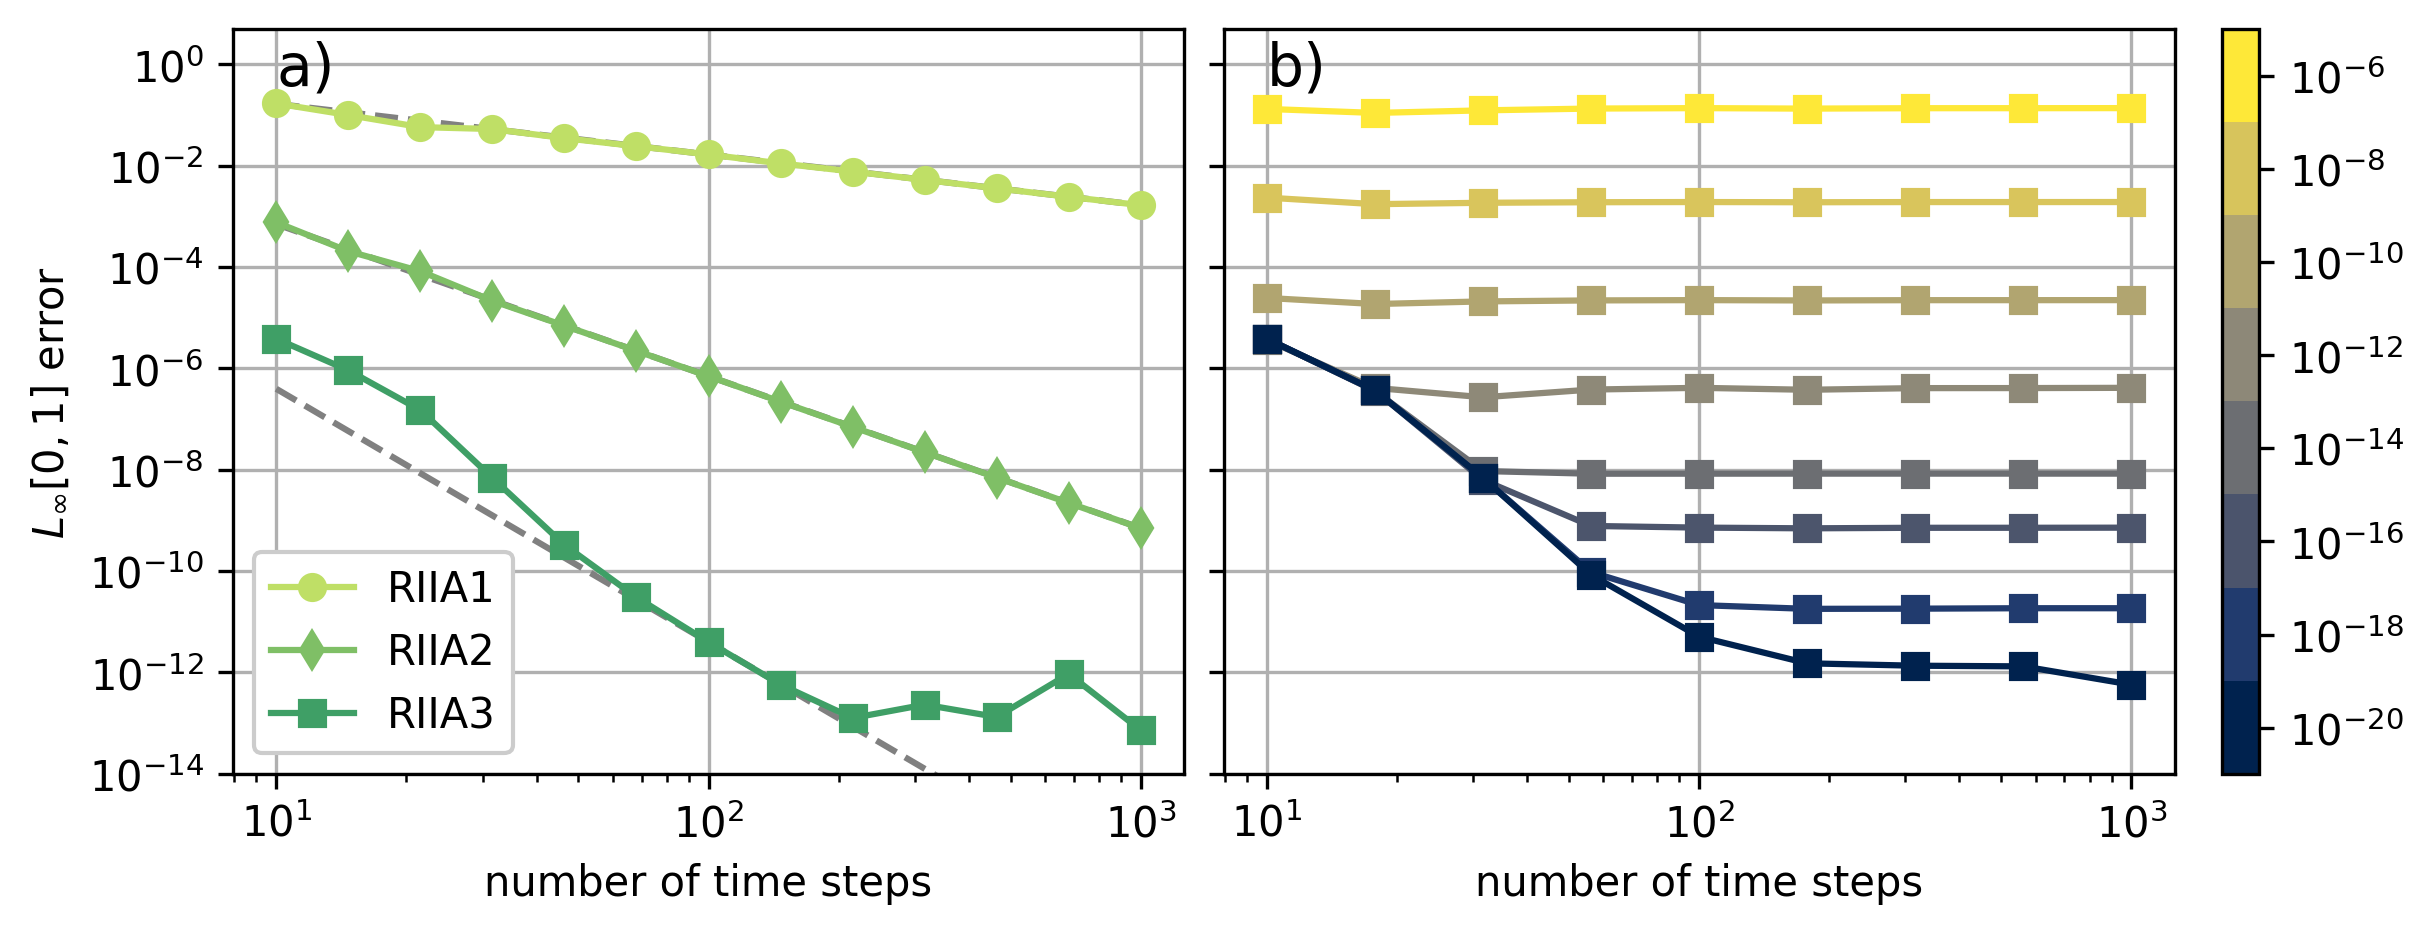

In [ ]:
fig, (ax_h, ax_RA) = plt.subplots(1,2,figsize=(8,3), dpi=300, constrained_layout=True)    

cmap = plt.get_cmap("summer_r")

for idt, scheme in enumerate(schemes): 
    ax_h.plot(1/hs_h, Linferror_h[scheme][6] * (hs_h/hs_h[6]) ** orders[scheme], color="gray", linestyle="--")
    ax_h.plot(1/hs_h, Linferror_h[scheme], label=scheme, marker=markers[scheme], color=cmap(1/4 + idt/4))

ax_h.text(10, 0.4, r'a)', fontsize=14)

ax_h.set_xlabel(r'number of time steps')
ax_h.set_ylabel(r"$L_\infty[0,1]$ error")
ax_h.set_xscale("log")
ax_h.set_yscale("log")
ax_h.set_ylim([1e-14,5e0])
ax_h.grid('on')
ax_h.legend(framealpha=1)



cmap = plt.get_cmap("cividis")

for idt, tol in enumerate(tolerances): 
    ax_RA.plot(1/hs_RA, Linferror_RA[tol], marker="s", color=cmap(1-idt/7-1e-12))

ax_RA.text(10, 0.4, r'b)', fontsize=14)

ax_RA.set_xlabel(r'number of time steps')

ax_RA.set_xscale("log")
ax_RA.set_yscale("log")
ax_RA.set_yticklabels([])

ax_RA.set_ylim([1e-14,5e0])
ax_RA.grid('on')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.BoundaryNorm([1e-21,1e-19,1e-17,1e-15,1e-13,1e-11,1e-9,1e-7,1e-5], cmap.N))
cbar = fig.colorbar(sm, ax=ax_RA, ticks=tolerances)
cbar.ax.set_yticks([5e-20,5e-18,5e-16,5e-14,5e-12,5e-10,5e-8,5e-6])
cbar.ax.set_yticklabels([r"$10^{-20}$", r"$10^{-18}$", r"$10^{-16}$", r"$10^{-14}$", r"$10^{-12}$", r"$10^{-10}$", r"$10^{-8}$", r"$10^{-6}$"])
cbar.ax.minorticks_off()

fig.savefig("Images/ExpGamma6_combined.pdf", bbox_inches="tight")